# 从TIS到SC，<font color='red'>重新理解LLM RL中的训推不一致</font>
- https://zhuanlan.zhihu.com/p/2087258204770145562

过去一段时间，SC（score centering）算法比较火热。借这个机会，正好学习了下 SC 论文中的公式推导，并复习了下之前一些 TIS 的相关论文，借这篇文章系统梳理一下 LLM RL 中的 TIM（Training Inference Mismatch）问题的根源以及解决方法。

## 为什么关注 on-policy LLM RL
首先我们明确下，下面的讨论统一针对 on-policy 的 LLM RL。那为什么我们执着于将 on-policy 的 LLM RL 变得更加稳定呢？

一种直观的理解是，on-policy RL 真正实现了模型自身采样，与环境交互，并利用环境的真实反馈来更新自身参数。on-policy 的程度越高，更新的梯度方向越准确，收敛速度越快（类似我们日常通过考试成果来反馈自身，利用昨天的考试成绩反馈来反思自身，和利用一个月前的考试成绩来反思自身，带来的效果自然不相同）。

而从数学的角度上来说，我们 RL 最本质优化的目标函数是：

In [1]:
from IPython.display import Image

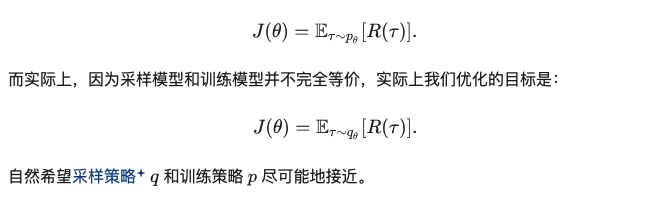

In [3]:
Image(filename='./Image/tis_01.png')

## LLM RL 中的 TIM 从何而来
在传统的 RL 中，模型和对应的 action space 一般比较小，推理的开销相对来说也没那么大，我们可以较为轻松地做到采样模型和训练模型的一致。

而在 LLM RL 中，因为其自回归生成 next token 的特性，我们必须采用一些现代的推理引擎 vLLM、SGLang 对推理过程进行优化，包括但不限于量化推理、KV cache 压缩、kernel 优化。种种这些为了加快实际推理速度做的优化，实际上都会导致同样的一段 seq，在训练引擎（Megatron）和推理引擎下会得到不同的 logits 结果。同时，因为浮点数本身计算顺序就会带来误差，这更加重了这些 mismatch。

同时在实际应用中，为了加快 LLM RL 的速度，我们往往还会采用诸如 fully-async、partial rollout，以及甚至同一 rollout batch 中被切分成若干个 mini-batch，而导致的一个 global batch size 中不同样本也对应了不同版本的模型。

总结下来，如果我们定义实际采样的模型策略为 q，训练的模型为 p，那么对于同一个 token，可能导致 p 和 q
出现不同预测 logits 的因素可能有：

1. 训练引擎和推理引擎的精度差异、模型量化导致的差异、浮点数误差导致的差异等等。
2. 因为采用异步 RL 训练而导致的训练策略 p 和推理策略 q的模型参数版本差异。
3. 采用 partial rollout 时，一个轨迹可能横跨多个推理策略版本而导致的 staleness。
4. 同一 rollout batch 被切成多个 mini-batch，后续 optimizer update 已在使用较旧策略的数据。


## 从 IS 到 TIS
而为了解决这个问题，最早被提出用来解决的就是 IS（importance sampling，重要性采样）。TIS 通过加入重要性采样权重，将我们实际优化的目标函数变为：




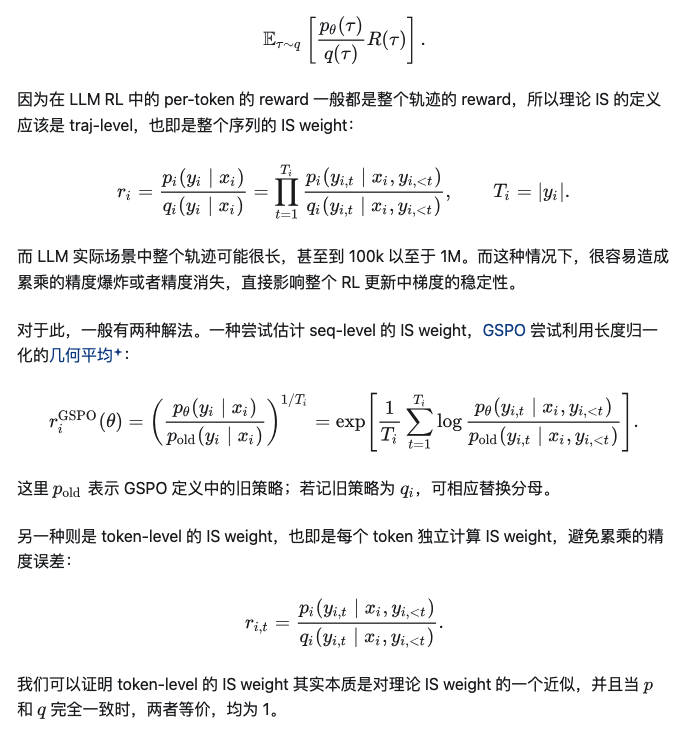

In [4]:
Image(filename='./Image/tis_02.png')

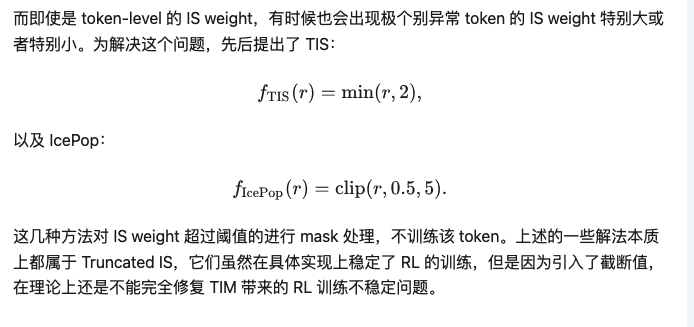

In [5]:
Image(filename='./Image/tis_03.png')

## 从 score 的期望理解 drift
SC（score centering）这篇论文则是首先从 TIM 为什么会导致 RL 训练不稳定进行理论分析，找到了更新梯度中的一个 drift 值，进而通过中心化论文中定义的 score 来消除 drift 带来的影响，稳定 RL 训练。

首先从 PG 出发，我们 RL 的目标函数是：

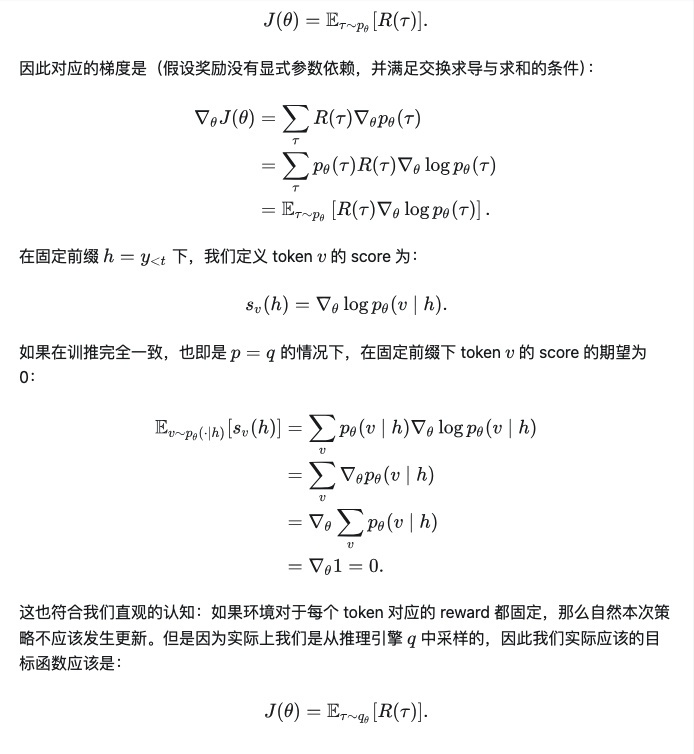

In [6]:
Image(filename='./Image/tis_04.png')

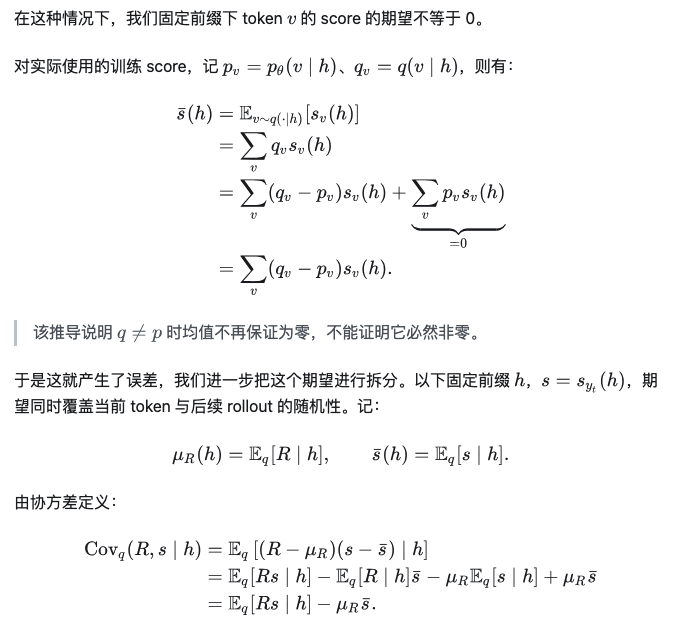

In [7]:
Image(filename='./Image/tis_05.png')

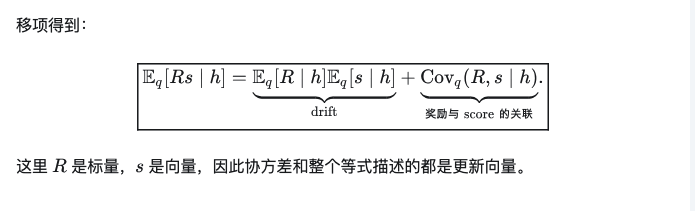

In [8]:
Image(filename='./Image/tis_06.png')

## drift 的含义：训练模型在向谁学习

需要注意的是，这里的 score 期望是对当前这个位置的候选 token v 求的期望，也即是：

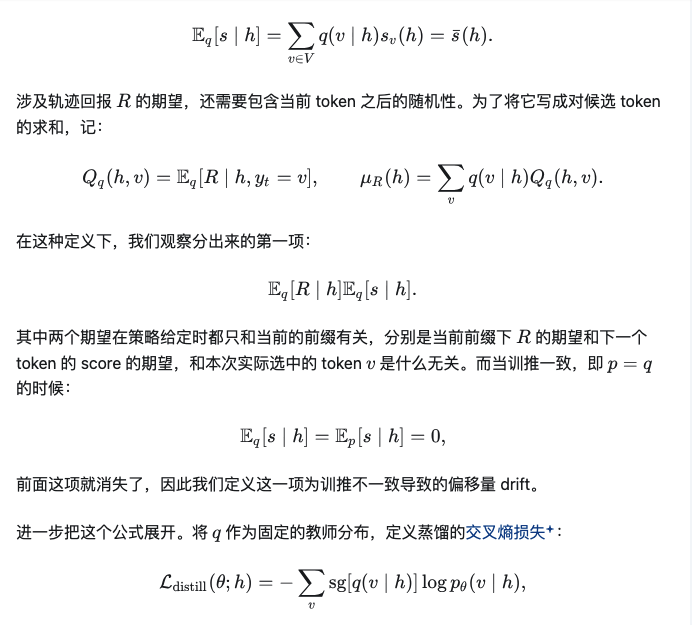

In [9]:
Image(filename='./Image/tis_07.png')

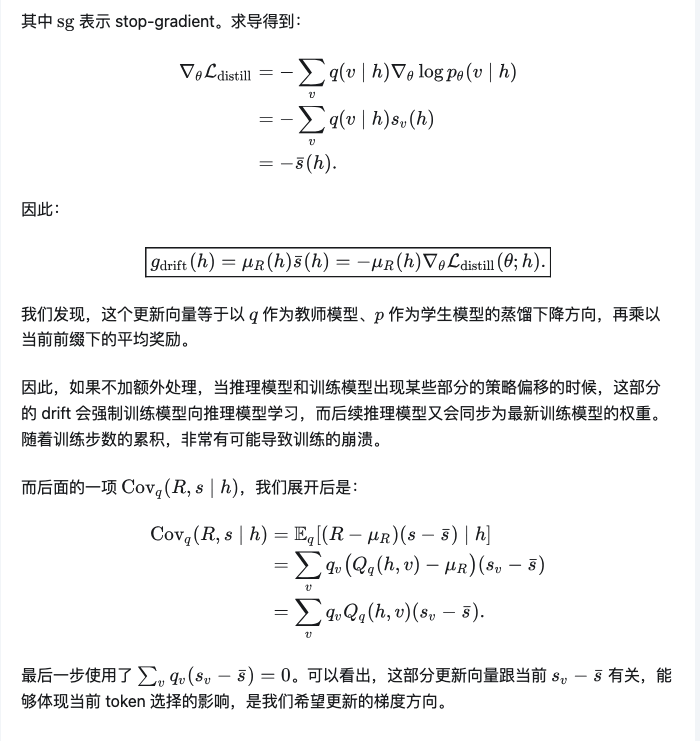

In [10]:
Image(filename='./Image/tis_08.png')

## Score centering：将 score 中心化
因此，SC 提出直接将更新公式中的 score 替换为中心化之后的 score 值，即令：




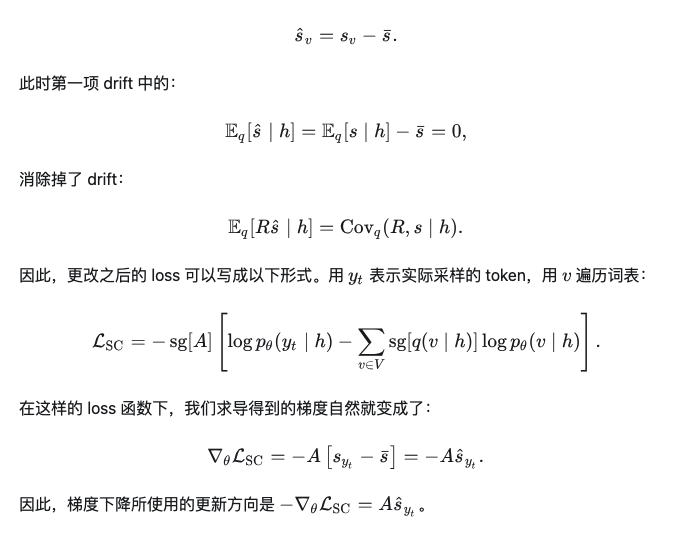

In [11]:
Image(filename='./Image/tis_09.png')

## 使用 top-k 近似计算中心化项

但是考虑实际的实现难度，LLM 整个词表非常大，每次把推理引擎中每个位置的全词表概率都存下来，存储和传输开销太大。因此，实际实现的时候，我们通过保存每个位置词表中概率最高的 top-k token 的 ID 和 log-probability（k 一般取 32 或 128）来近似计算。

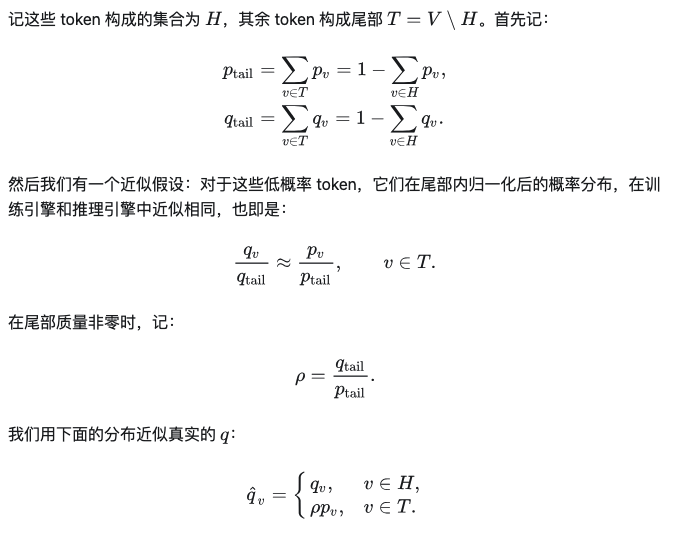

In [12]:
Image(filename='./Image/tis_10.png')

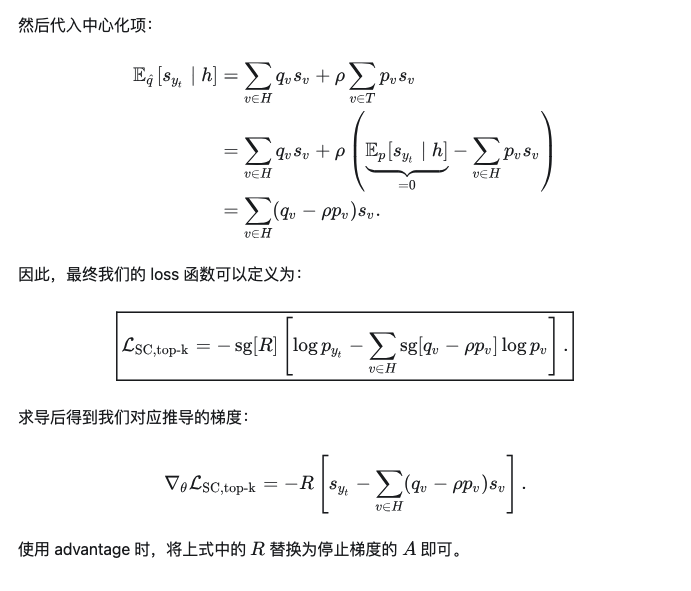

In [13]:
Image(filename='./Image/tis_11.png')

## 为什么还要将 TIS 和 SC 结合
但需要注意的一点是，这个 SC 算法虽然从理论上消除了 drift 对于 RL 训练造成的影响，但是并没有完全消除 TIM 对训练造成的影响，因为我们后一项协方差 $$Cov_q(R,s | h)$$还是基于推理模型 q 的，但是实际上我们希望它是基于训练框架 p的。因此，对于 RL 训练存在 off-policy 的情况下，我们依然推荐继续采用 TIS，将 TIS 和 SC 结合使用。

同时，在具体结合的时候，论文使用了一些小技巧：IS weight 没有放在 score 中心化的外面，而是先对 score 加权，再对加权后的 score 进行中心化。

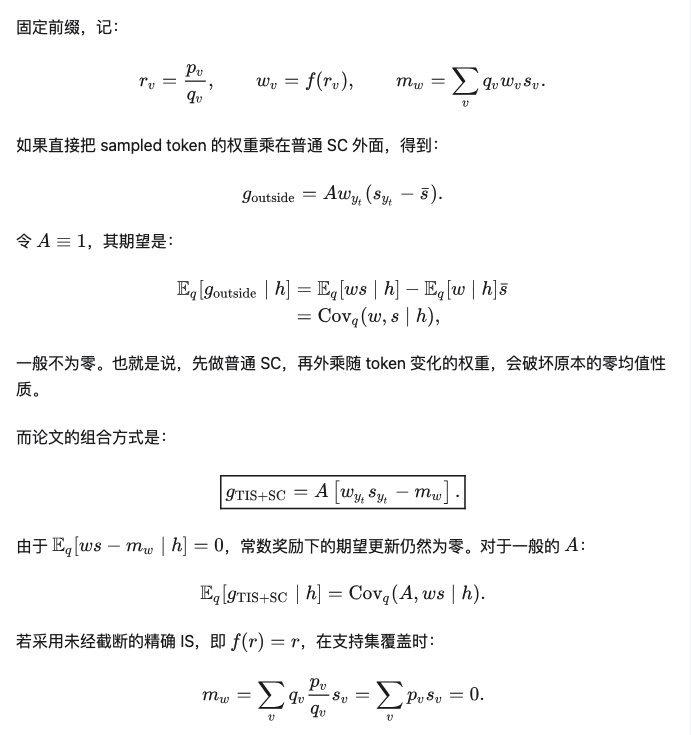

In [14]:
Image(filename='./Image/tis_12.png')

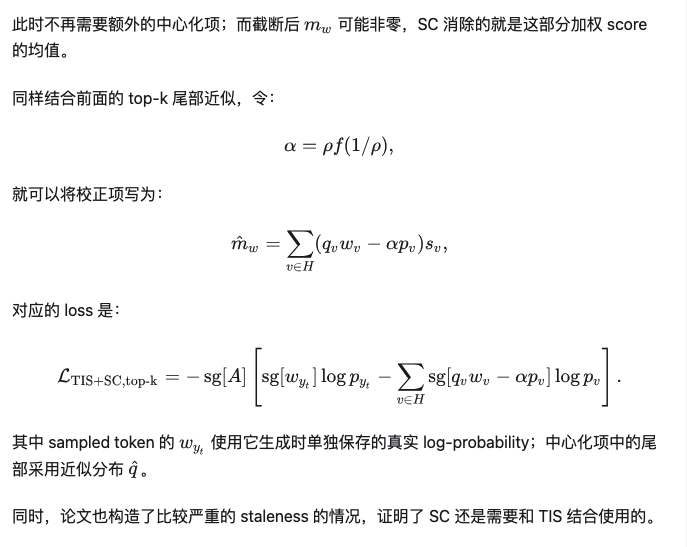

In [15]:
Image(filename='./Image/tis_13.png')

## 从 STE 和 BPO 的角度理解 SC
关于从 STE 和 BPO 的角度理解 SC，可以参考以下两篇博客：

- STE 视角  https://zhuanlan.zhihu.com/p/2085039491153139207
- BPO 视角  https://zhuanlan.zhihu.com/p/2084586770000261374
这部分后续有机会再继续补充。

## 参考文献
- SC：Martin Marek、Max Ryabinin. Score Centering Stabilizes Off-policy Reinforcement Learning. 2026.  https://arxiv.org/abs/2609.20807
- TIS 在 LLM 训推失配中的应用：Feng Yao 等. On the Rollout-Training Mismatch in Modern RL Systems. 2025. https://openreview.net/pdf?id=8MHqvb4lK9
- IcePop：Ling Team. Every Step Evolves: Scaling Reinforcement Learning for Trillion-Scale Thinking Model. 2025. https://arxiv.org/abs/2510.18855
- GSPO：Chujie Zheng 等. Group Sequence Policy Optimization. 2025.  https://arxiv.org/abs/2507.18071
- STE 视角博客：知乎文章。 https://zhuanlan.zhihu.com/p/2085039491153139207
- BPO 视角博客：知乎文章。 https://zhuanlan.zhihu.com/p/2084586770000261374
- SC和BPO参考博客：知乎文章。 https://zhuanlan.zhihu.com/p/2085051180716237979